In [4]:
import os 
import json 
from dotenv import  load_dotenv 
from typing import  Annotated,TypedDict,Dict,Literal
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import  ToolNode,tools_condition
from pydantic import  BaseModel,Field
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import  tool 
from langchain_groq import  ChatGroq



In [5]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")

In [6]:
class State (TypedDict):
    message=Annotated[list[BaseMessage],add_messages]
    next:str

In [ ]:
import os
from typing import Annotated, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")

In [3]:


# ==========================================
# 1. DEFINE SHARED GRAPH STATE
# ==========================================
# Annotated[list, add_messages] tells LangGraph to append new messages 
# to the existing list rather than overwriting it.
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next: str


In [4]:
# ==========================================
# 2. THE SUPERVISOR (ROUTER)
# ==========================================
# We define the options the supervisor is allowed to choose from.
# It can pick a worker, or it can pick "FINISH" to end the workflow.
members = ["Researcher", "Mathematician"]
options = ["FINISH"] + members

class RouteDecision(BaseModel):
    next: Literal["Researcher", "Mathematician", "FINISH"] = Field(
        description="The next agent to route the task to, or FINISH if the user's request is completely fulfilled."
    )

def supervisor_node(state: AgentState) -> dict:
    """The central manager that reads the conversation and decides the next step."""
    print("\n--- [SUPERVISOR] Deciding next step... ---")
    
    system_prompt = (
        "You are a supervisor managing a conversation between these workers: "
        f"{', '.join(members)}. "
        "Given the conversation history, who should act next? "
        "Each worker will perform a task and respond with their results. "
        "When all tasks are complete, respond with FINISH."
    )
    
    # We force the LLM to output ONLY our Pydantic schema using structured output
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    structured_llm = llm.with_structured_output(RouteDecision)
    decision = structured_llm.invoke(messages)
    
    print(f"Supervisor decided: {decision.next}")
    return {"next": decision.next}


In [5]:
# ==========================================
# 3. THE WORKER NODES
# ==========================================
def researcher_node(state: AgentState) -> dict:
    """Worker 1: Specialized in data retrieval."""
    print("--- [RESEARCHER] Executing... ---")
    # In a real app, this would use a tool like Tavily to search the web.
    # We append our result as an AIMessage so the supervisor sees it.
    result = "Microsoft's revenue was $245B in 2024 and $270B in 2025."
    return {"messages": [AIMessage(content=result, name="Researcher")]}

def mathematician_node(state: AgentState) -> dict:
    """Worker 2: Specialized in math."""
    print("--- [MATHEMATICIAN] Executing... ---")
    # In a real app, this would use a calculator tool.
    result = "The growth from $245B to $270B is approximately 10.2%."
    return {"messages": [AIMessage(content=result, name="Mathematician")]}


In [6]:
# ==========================================
# 4. CONDITIONAL ROUTING EDGE
# ==========================================
def router_edge(state: AgentState) -> str:
    """Reads the 'next' value set by the supervisor and returns the node name."""
    # This string must exactly match the node names registered in the graph.
    return state["next"]


In [13]:
from langgraph.graph import START, END

# Assemble the Graph
builder = StateGraph(AgentState)

# Add all nodes
builder.add_node("Supervisor", supervisor_node)
builder.add_node("Researcher", researcher_node)
builder.add_node("Mathematician", mathematician_node)

# Set the entry point
builder.add_edge(START, "Supervisor")

# Add the conditional edge with an explicit path mapping dictionary
builder.add_conditional_edges(
    "Supervisor", 
    router_edge,
    {
        "Researcher": "Researcher",
        "Mathematician": "Mathematician",
        "FINISH": END
    }
)

# Every worker routes back to the Supervisor to create the feedback loop
builder.add_edge("Researcher", "Supervisor")
builder.add_edge("Mathematician", "Supervisor")

# Compile
graph = builder.compile()

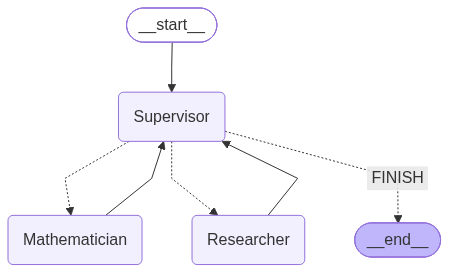

In [14]:
from IPython.display import display ,Image


display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:








# ==========================================
# 6. EXECUTE THE WORKFLOW
# ==========================================
if __name__ == "__main__":
    initial_message = HumanMessage(content="What was Microsoft's revenue growth rate from 2024 to 2025?")
    
    # LangGraph streams the updates as they happen
    for event in graph.stream({"messages": [initial_message]}):
        for node_name, state_update in event.items():
            print(f"Finished node: {node_name}")
            if "messages" in state_update:
                print(f"Message output: {state_update['messages'][-1].content}\n")


--- [SUPERVISOR] Deciding next step... ---
Supervisor decided: Researcher
Finished node: Supervisor
--- [RESEARCHER] Executing... ---
Finished node: Researcher
Message output: Microsoft's revenue was $245B in 2024 and $270B in 2025.


--- [SUPERVISOR] Deciding next step... ---
Supervisor decided: Mathematician
Finished node: Supervisor
--- [MATHEMATICIAN] Executing... ---
Finished node: Mathematician
Message output: The growth from $245B to $270B is approximately 10.2%.


--- [SUPERVISOR] Deciding next step... ---


Task Supervisor with path ('__pregel_pull', 'Supervisor') wrote to unknown channel branch:to:FINISH, ignoring it.


Supervisor decided: FINISH
Finished node: Supervisor
